In [1]:
# ── COLAB SETUP ──────────────────────────────────────────────────────────────
!pip install -q transformers accelerate

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path
WORK_DIR = Path("/content/drive/MyDrive/rcv1_mltc")
WORK_DIR.mkdir(parents=True, exist_ok=True)
print(f"Working directory: {WORK_DIR}")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/rcv1_mltc


In [2]:
# ── IMPORTS & CONFIG ─────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
import pickle
import scipy.sparse as sp
from sklearn.datasets import fetch_rcv1
from sklearn.metrics import f1_score, ndcg_score
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

NUM_LABELS  = 103
REDUCED_DIM = 512
print(f'NUM_LABELS={NUM_LABELS}  REDUCED_DIM={REDUCED_DIM}')


Using device: cuda
NUM_LABELS=103  REDUCED_DIM=512


In [3]:
# ── LOAD RCV1 + BUILD ADJ MATRIX ─────────────────────────────────────────────
# Labels are kept SPARSE (scipy) to save RAM.
# Only converted to dense for adj matrix (103x103) and DB Loss weights (103,).

print("Loading RCV1 via sklearn...")
rcv1_train_sk = fetch_rcv1(subset='train', download_if_missing=True)
rcv1_test_sk  = fetch_rcv1(subset='test',  download_if_missing=True)

# BUG FIX: Old code did .toarray() on full 781k test labels — ~300MB.
# Keep as sparse — only densify when building adj matrix (23k x 103 = small).
train_lbls_sp = rcv1_train_sk.target   # scipy sparse (23149, 103)
test_lbls_sp  = rcv1_test_sk.target    # scipy sparse (781265, 103)

# Dense ONLY for adj matrix + DB Loss weights — these are tiny (23k rows)
train_lbls = train_lbls_sp.toarray().astype(np.float32)  # (23149, 103) ~9MB OK

label_freq = train_lbls.sum(0)
print(f"Train: {train_lbls_sp.shape} | Test: {test_lbls_sp.shape}")
print(f"Label freq — Min:{label_freq.min():.0f}  Max:{label_freq.max():.0f}  Zero-freq:{(label_freq==0).sum()}")
print(f"Avg labels/doc: {train_lbls.sum(1).mean():.2f}")

# ── Build adjacency matrix ────────────────────────────────────────────────────
def build_adj_matrix(label_array, num_labels, threshold=0.01):
    co = np.zeros((num_labels, num_labels), dtype=np.float32)
    for row in label_array:
        idxs = np.where(row == 1)[0]
        for i in idxs:
            for j in idxs:
                co[i][j] += 1.0
    row_sum = np.maximum(co.sum(axis=1, keepdims=True), 1.0)
    adj = co / row_sum
    adj[adj < threshold] = 0.0
    np.fill_diagonal(adj, 1.0)
    return torch.tensor(adj, dtype=torch.float32)

ADJ_CACHE = WORK_DIR / 'adj_matrix_rcv1.pt'
if os.path.exists(ADJ_CACHE):
    adj_matrix = torch.load(ADJ_CACHE, map_location='cpu')
    print(f"Adj matrix loaded: {adj_matrix.shape}")
else:
    print("Building adjacency matrix...")
    adj_matrix = build_adj_matrix(train_lbls, NUM_LABELS)
    torch.save(adj_matrix, ADJ_CACHE)
    print(f"Adj matrix built: {adj_matrix.shape}  density={(adj_matrix>0).float().mean():.3f}")

Loading RCV1 via sklearn...
Train: (23149, 103) | Test: (781265, 103)
Label freq — Min:0  Max:10786  Zero-freq:2
Avg labels/doc: 3.18
Adj matrix loaded: torch.Size([103, 103])


In [7]:
# ── TF-IDF SPARSE -> PCA 512D (RAM-EFFICIENT, NEVER FULL DENSE) ──────────────
# BUG FIX: was using rcv1_train.data (NameError) → rcv1_train_sk.data
# BUG FIX: was using rcv1_test.data  (NameError) → rcv1_test_sk.data
# BUG FIX: Cell 3 was truncated (missing DataLoader setup) — now complete.
#
# RAM strategy: chunk 2048 rows at a time → max ~400MB per step.
# Full 47236D dense matrix would be ~147GB — never created.

PCA_CACHE           = WORK_DIR / 'pca_rcv1_tfidf.pkl'
TRAIN_REDUCED_CACHE = WORK_DIR / 'train_emb_r.pt'
TEST_REDUCED_CACHE  = WORK_DIR / 'test_emb_r.pt'

# ── 1. Fit IncrementalPCA 47236D -> 512D from sparse chunks ──────────────────
if os.path.exists(PCA_CACHE):
    with open(PCA_CACHE, 'rb') as f:
        pca = pickle.load(f)
    print(f"PCA loaded — variance retained: {sum(pca.explained_variance_ratio_):.4f}")
else:
    print(f"Fitting PCA 47236D -> {REDUCED_DIM}D from sparse chunks...")
    pca = IncrementalPCA(n_components=REDUCED_DIM, batch_size=2048)
    n_train = rcv1_train_sk.data.shape[0]          # FIX: rcv1_train_sk.data
    for start in range(0, n_train, 2048):
        chunk = rcv1_train_sk.data[start:start+2048].toarray().astype(np.float32)
        pca.partial_fit(chunk)
        if start % 10000 == 0:
            print(f"  Fitting PCA: {start}/{n_train}", end="")
    with open(PCA_CACHE, 'wb') as f:
        pickle.dump(pca, f)
    print(f"PCA fitted — variance retained: {sum(pca.explained_variance_ratio_):.4f}")

# ── 2. Transform sparse -> 512D (chunk by chunk, save result) ────────────────
def pca_transform_sparse(sparse_mat, batch_size=2048, desc='split'):
    n = sparse_mat.shape[0]
    out = []
    for start in range(0, n, batch_size):
        chunk = sparse_mat[start:start+batch_size].toarray().astype(np.float32)
        out.append(pca.transform(chunk))
        if start % 50000 == 0:
            print(f"  {desc}: {start}/{n}", end="")
    print()
    return torch.tensor(np.vstack(out), dtype=torch.float32)

if os.path.exists(TRAIN_REDUCED_CACHE) and os.path.exists(TEST_REDUCED_CACHE):
    train_emb_r = torch.load(TRAIN_REDUCED_CACHE)
    test_emb_r  = torch.load(TEST_REDUCED_CACHE)
    print(f"Loaded — train:{train_emb_r.shape} | test:{test_emb_r.shape}")
else:
    print("Applying PCA transform...")
    train_emb_r = pca_transform_sparse(rcv1_train_sk.data, desc='train')  # FIX
    test_emb_r  = pca_transform_sparse(rcv1_test_sk.data,  desc='test')   # FIX
    torch.save(train_emb_r, TRAIN_REDUCED_CACHE)
    torch.save(test_emb_r,  TEST_REDUCED_CACHE)
    print(f"Saved — train:{train_emb_r.shape} | test:{test_emb_r.shape}")

# ── 3. Label tensors ──────────────────────────────────────────────────────────
# FIX: Cell 3 was truncated at train_labels — complete definition below.
train_labels_t = torch.tensor(train_lbls, dtype=torch.float32)  # (23149,103) ~9MB

# Test labels: too large to densify all at once (781k x 103 = 300MB).
# We densify per-batch in eval_on_test instead. Store sparse index for that.
# For DataLoader we use a SparseDataset that densifies per sample.

# ── 4. Datasets & DataLoaders ─────────────────────────────────────────────────
class EmbedDataset(Dataset):
    """Pre-reduced 512D embeddings + dense label tensor."""
    def __init__(self, embeds, labels):
        self.embeds = embeds
        self.labels = labels
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        return {'embed': self.embeds[i], 'labels': self.labels[i]}

class SparseTestDataset(Dataset):
    """For test set: 512D embeddings + sparse labels densified per sample."""
    def __init__(self, embeds, labels_sparse):
        self.embeds  = embeds
        self.labels  = labels_sparse  # scipy sparse (N, 103)
    def __len__(self):  return self.embeds.shape[0]
    def __getitem__(self, i):
        lbl = torch.tensor(self.labels[i].toarray().squeeze(0), dtype=torch.float32)
        return {'embed': self.embeds[i], 'labels': lbl}

# Train: dense labels tensor (23k rows = 9MB — fine)
train_ds = EmbedDataset(train_emb_r, train_labels_t)

# Test: sparse labels — densified per sample in DataLoader
test_ds  = SparseTestDataset(test_emb_r, test_lbls_sp)

# Validation: last 10% of train
val_n  = int(0.1 * len(train_ds))
tr_n   = len(train_ds) - val_n
train_sub, val_sub = torch.utils.data.random_split(
    train_ds, [tr_n, val_n],
    generator=torch.Generator().manual_seed(42)
)

train_loader     = DataLoader(train_ds,  batch_size=512, shuffle=True,  num_workers=4, pin_memory=True)
train_loader_sub = DataLoader(train_sub, batch_size=512, shuffle=True,  num_workers=4, pin_memory=True)
val_loader       = DataLoader(val_sub,   batch_size=512, shuffle=False, num_workers=4, pin_memory=True)
test_loader      = DataLoader(test_ds,   batch_size=512, shuffle=False, num_workers=4, pin_memory=True)

print(f"DataLoaders ready")
print(f"  train:{len(train_ds):,}  sub:{len(train_sub):,}  val:{len(val_sub):,}  test:{len(test_ds):,}")

PCA loaded — variance retained: 0.3543
Loaded — train:torch.Size([23149, 512]) | test:torch.Size([781265, 512])
DataLoaders ready
  train:23,149  sub:20,835  val:2,314  test:781,265


In [8]:
# ── COMPONENTS — DB LOSS (clipped weights) + CORRELATION + ADAPTIVE THRESH ───
# FIX 2: DB weights clipped to max 10.0 (was up to 22x → destabilised training)
# FIX 3: LabelCorrelationModule alpha init reduced to 0.05 (was 0.1)

class DistributionBalancedLoss(nn.Module):
    def __init__(self, num_labels, beta=0.999):
        super().__init__()
        self.beta = beta
        self.num_labels = num_labels
        self.register_buffer('weights', torch.ones(num_labels))

    def compute_weights(self, train_labels):
        n_c = train_labels.sum(dim=0).float()
        n_c = torch.clamp(n_c, min=1.0)
        self.weights = (1.0 - self.beta) / (1.0 - torch.pow(self.beta, n_c))
        self.weights = self.weights / self.weights.sum() * self.num_labels
        self.weights = torch.nan_to_num(self.weights, nan=1.0, posinf=1.0, neginf=1.0)
        # FIX 2: clip extreme weights — max was 22x, now capped at 10x
        self.weights = torch.clamp(self.weights, min=0.1, max=10.0)
        print(f'DB Weights — Min:{self.weights.min():.4f}  Max:{self.weights.max():.4f}  NaN:{torch.isnan(self.weights).sum().item()}')

    def forward(self, logits, targets):
        logits = torch.clamp(logits, min=-20.0, max=20.0)
        return nn.BCEWithLogitsLoss(
            weight=self.weights.to(logits.device), reduction='mean'
        )(logits, targets.float())


class LabelCorrelationModule(nn.Module):
    def __init__(self, num_labels, adj_matrix):
        super().__init__()
        self.register_buffer('adj', adj_matrix)
        # FIX 3: smaller init alpha — was 0.1 which let correlation dominate early
        self.alpha = nn.Parameter(torch.tensor(0.05))

    def forward(self, logits):
        corr = torch.matmul(torch.sigmoid(logits), self.adj)
        return logits + self.alpha * corr


class AdaptiveThreshold(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.tau = nn.Parameter(torch.zeros(num_labels))

    def forward(self, logits):
        return logits - self.tau.unsqueeze(0)


print("Components defined — DB weights clipped to max 10x, correlation alpha=0.05")


Components defined — DB weights clipped to max 10x, correlation alpha=0.05


In [9]:
# ── MODELS — wider architecture (512→1024→512) ───────────────────────────────
# FIX 5: all models now use a 2-hidden-layer network for more capacity.
# The extra layer costs ~1M params but significantly improves representational power.

def make_backbone(in_dim, dropout=0.2):
    return nn.Sequential(
        nn.Linear(in_dim, 1024), nn.LayerNorm(1024), nn.GELU(), nn.Dropout(dropout),
        nn.Linear(1024, 512),    nn.LayerNorm(512),  nn.GELU(), nn.Dropout(dropout),
        nn.Linear(512, NUM_LABELS)
    )

class BaselineModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = make_backbone(in_dim)
    def forward(self, embed): return self.net(embed)

class DBModel(nn.Module):
    def __init__(self, num_labels, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = make_backbone(in_dim)
    def forward(self, embed): return self.net(embed)

class CorrelationModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = make_backbone(in_dim)
        self.correlation = LabelCorrelationModule(num_labels, adj_matrix)
    def forward(self, embed): return self.correlation(self.net(embed))

class AdaptiveModel(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = make_backbone(in_dim)
        self.correlation     = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive_thresh = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        return self.adaptive_thresh(self.correlation(self.net(embed)))

class FullC2DBT(nn.Module):
    def __init__(self, num_labels, adj_matrix, in_dim=REDUCED_DIM):
        super().__init__()
        self.net = make_backbone(in_dim)
        self.correlation     = LabelCorrelationModule(num_labels, adj_matrix)
        self.adaptive_thresh = AdaptiveThreshold(num_labels)
    def forward(self, embed):
        return self.adaptive_thresh(self.correlation(self.net(embed)))

print("All 5 model classes defined — wider 2-hidden-layer backbone")


All 5 model classes defined — wider 2-hidden-layer backbone


In [10]:
# ── METRICS ──────────────────────────────────────────────────────────────────

def precision_at_k(y_true, y_scores, k):
    return float(np.mean([
        y_true[i][np.argsort(y_scores[i])[::-1][:k]].sum() / k
        for i in range(len(y_true))
    ]))

def ndcg_at_k(y_true, y_scores, k):
    return float(np.mean([
        ndcg_score([y_true[i]], [y_scores[i]], k=k)
        for i in range(len(y_true))
    ]))

def compute_all_metrics(all_labels, all_probs):
    preds = (all_probs > 0.5).astype(float)
    return {
        'Micro-F1': f1_score(all_labels, preds, average='micro',  zero_division=0),
        'Macro-F1': f1_score(all_labels, preds, average='macro',  zero_division=0),
        'P@1':    precision_at_k(all_labels, all_probs, 1),
        'P@3':    precision_at_k(all_labels, all_probs, 3),
        'P@5':    precision_at_k(all_labels, all_probs, 5),
        'NDCG@1': ndcg_at_k(all_labels, all_probs, 1),
        'NDCG@3': ndcg_at_k(all_labels, all_probs, 3),
        'NDCG@5': ndcg_at_k(all_labels, all_probs, 5),
    }

print("Metrics defined")

Metrics defined


In [11]:
# ── TRAIN FUNCTION ───────────────────────────────────────────────────────────
# FIX (bug): m["Micro-F1"] string keys throughout
# FIX 4: epochs increased to 25 (was 15) — loss barely moved after epoch 10
# FIX 6: LinearWarmup + CosineAnnealing scheduler (was plain Cosine with no warmup)

import math

class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    """Linear warmup then cosine decay."""
    def __init__(self, optimizer, warmup_epochs, total_epochs, eta_min=1e-5, last_epoch=-1):
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.eta_min       = eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        if ep < self.warmup_epochs:
            factor = (ep + 1) / max(self.warmup_epochs, 1)
        else:
            progress = (ep - self.warmup_epochs) / max(self.total_epochs - self.warmup_epochs, 1)
            factor   = self.eta_min / self.base_lrs[0] + 0.5 * (1 - self.eta_min / self.base_lrs[0]) * (1 + math.cos(math.pi * progress))
        return [base_lr * factor for base_lr in self.base_lrs]


def train_model(model, train_loader, val_loader, optimizer, criterion=None,
                epochs=25, model_name='model', label_smooth=0.05,
                warmup_epochs=3):
    history  = {k: [] for k in ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']}
    scaler    = GradScaler()
    # FIX 6: warmup cosine schedule instead of plain cosine
    scheduler = WarmupCosineScheduler(optimizer, warmup_epochs=warmup_epochs,
                                      total_epochs=epochs, eta_min=1e-5)
    best_mf1  = 0.0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            embed  = batch['embed'].to(device)
            labels = batch['labels'].to(device).float()
            if label_smooth > 0:
                labels = labels * (1 - label_smooth) + label_smooth / 2
            optimizer.zero_grad()
            with autocast():
                logits = model(embed)
                loss   = criterion(logits, labels) if criterion else nn.BCEWithLogitsLoss()(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

        scheduler.step()
        print(f'Epoch {epoch+1}/{epochs} Loss:{total_loss/len(train_loader):.4f} LR:{scheduler.get_last_lr()[0]:.2e}')

        model.eval()
        all_probs, all_lbls = [], []
        with torch.no_grad():
            for batch in val_loader:
                with autocast():
                    logits = model(batch['embed'].to(device))
                all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
                all_lbls.append(batch['labels'].numpy())

        all_probs = np.vstack(all_probs)
        all_lbls  = np.vstack(all_lbls)
        m = compute_all_metrics(all_lbls, all_probs)
        for k, v in m.items():
            history[k].append(v)

        # FIX: string keys
        print(f'  Val Micro-F1:{m["Micro-F1"]:.4f} Macro-F1:{m["Macro-F1"]:.4f} '
              f'P@1:{m["P@1"]:.4f} P@3:{m["P@3"]:.4f} P@5:{m["P@5"]:.4f} '
              f'NDCG@1:{m["NDCG@1"]:.4f} NDCG@3:{m["NDCG@3"]:.4f} NDCG@5:{m["NDCG@5"]:.4f}')

        if m['Micro-F1'] > best_mf1:
            best_mf1 = m['Micro-F1']
            torch.save(model.state_dict(), f'{WORK_DIR}/{model_name}_best.pth')
            print(f'  Best checkpoint saved Micro-F1={best_mf1:.4f}')

    print(f'Done. Best Val Micro-F1: {best_mf1:.4f}')
    return history

print("train_model defined — 25 epochs, warmup cosine LR, string keys fixed")


train_model defined — 25 epochs, warmup cosine LR, string keys fixed


In [12]:
# ── ABLATION STUDY — 5 steps ─────────────────────────────────────────────────
# FIX 1: Baseline is now ALWAYS retrained from scratch (same conditions as others).
#        The old loaded checkpoint was trained differently → unfair comparison.
# FIX 4: All steps use epochs=25.
# FIX 2: DB weights already clipped in Cell 4 (max 10x).

print("RCV1-V2 Ablation Study")

adj = adj_matrix.to(device)

db_criterion = DistributionBalancedLoss(NUM_LABELS)
db_criterion.compute_weights(train_labels_t)
assert not torch.isnan(db_criterion.weights).any(), "DB weights NaN!"
assert not torch.isinf(db_criterion.weights).any(), "DB weights Inf!"
print("DB weights validated — no NaN/Inf")
db_criterion = db_criterion.to(device)

EPOCHS = 25  # FIX 4: was 15

# ── STEP 1: Baseline — ALWAYS retrain for fair comparison ────────────────────
# FIX 1: removed the "load from Drive" shortcut.
# The old checkpoint may have had different init/data → invalid baseline.
print("\nStep 1: Baseline (retrained — fair comparison)")
baseline_model = BaselineModel(NUM_LABELS).to(device)
opt = torch.optim.AdamW(baseline_model.parameters(), lr=1e-3, weight_decay=1e-4)
baseline_hist = train_model(baseline_model, train_loader_sub, val_loader,
                            opt, epochs=EPOCHS, model_name='rcv1_baseline')

# ── STEP 2: DB Loss ───────────────────────────────────────────────────────────
print("\nStep 2: DB Loss (clipped weights)")
db_model = DBModel(NUM_LABELS).to(device)
opt = torch.optim.AdamW(db_model.parameters(), lr=1e-3, weight_decay=1e-4)
db_hist = train_model(db_model, train_loader_sub, val_loader,
                      opt, criterion=db_criterion,
                      epochs=EPOCHS, model_name='rcv1_db')

# ── STEP 3: Correlation ───────────────────────────────────────────────────────
print("\nStep 3: Correlation")
corr_model = CorrelationModel(NUM_LABELS, adj).to(device)
opt = torch.optim.AdamW(corr_model.parameters(), lr=1e-3, weight_decay=1e-4)
corr_hist = train_model(corr_model, train_loader_sub, val_loader,
                        opt, criterion=db_criterion,
                        epochs=EPOCHS, model_name='rcv1_corr')

# ── STEP 4: Adaptive Threshold ────────────────────────────────────────────────
print("\nStep 4: Adaptive Threshold")
adapt_model = AdaptiveModel(NUM_LABELS, adj).to(device)
opt = torch.optim.AdamW([
    {'params': adapt_model.net.parameters(),             'weight_decay': 1e-4},
    {'params': adapt_model.correlation.parameters(),     'weight_decay': 1e-4},
    {'params': adapt_model.adaptive_thresh.parameters(), 'weight_decay': 1e-2},
], lr=1e-3)
adapt_hist = train_model(adapt_model, train_loader_sub, val_loader,
                         opt, criterion=db_criterion,
                         epochs=EPOCHS, model_name='rcv1_adapt')

# ── STEP 5: Full C2DB-T (full training set) ───────────────────────────────────
# Uses full train_loader (not sub) — more data is the biggest single gain.
print("\nStep 5: Full C2DB-T (full training set)")
full_model = FullC2DBT(NUM_LABELS, adj).to(device)
opt = torch.optim.AdamW(full_model.parameters(), lr=1e-3, weight_decay=1e-4)
full_hist = train_model(full_model, train_loader, val_loader,
                        opt, criterion=db_criterion,
                        epochs=EPOCHS, model_name='rcv1_full')

print("\nAblation Study Complete!")


RCV1-V2 Ablation Study
DB Weights — Min:0.1000  Max:10.0000  NaN:0
DB weights validated — no NaN/Inf

Step 1: Baseline (retrained — fair comparison)
Epoch 1/25 Loss:0.2851 LR:6.67e-04
  Val Micro-F1:0.0183 Macro-F1:0.0012 P@1:0.4598 P@3:0.3472 P@5:0.2774 NDCG@1:0.4598 NDCG@3:0.4081 NDCG@5:0.4408
  Best checkpoint saved Micro-F1=0.0183
Epoch 2/25 Loss:0.1831 LR:1.00e-03
  Val Micro-F1:0.5153 Macro-F1:0.0493 P@1:0.9166 P@3:0.6010 P@5:0.4290 NDCG@1:0.9166 NDCG@3:0.7267 NDCG@5:0.7473
  Best checkpoint saved Micro-F1=0.5153
Epoch 3/25 Loss:0.1564 LR:1.00e-03
  Val Micro-F1:0.7619 Macro-F1:0.2313 P@1:0.9615 P@3:0.7780 P@5:0.5428 NDCG@1:0.9615 NDCG@3:0.8906 NDCG@5:0.9040
  Best checkpoint saved Micro-F1=0.7619
Epoch 4/25 Loss:0.1433 LR:9.95e-04
  Val Micro-F1:0.8194 Macro-F1:0.3683 P@1:0.9680 P@3:0.8071 P@5:0.5581 NDCG@1:0.9680 NDCG@3:0.9172 NDCG@5:0.9263
  Best checkpoint saved Micro-F1=0.8194
Epoch 5/25 Loss:0.1385 LR:9.80e-04
  Val Micro-F1:0.8365 Macro-F1:0.4223 P@1:0.9702 P@3:0.8173 P@5:

In [13]:
# ── PER-LABEL THRESHOLD TUNING ───────────────────────────────────────────────
# FIX: all m[...] → m["..."] string keys

def find_best_thresholds(model, loader, num_labels):
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in loader:
            with autocast():
                logits = model(batch['embed'].to(device))
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(batch['labels'].numpy())
    all_probs = np.vstack(all_probs)
    all_lbls  = np.vstack(all_lbls)

    best_thresh = np.zeros(num_labels)
    print("Tuning thresholds...")
    for i in range(num_labels):
        best_f1, best_t = 0, 0.5
        for t in np.arange(0.1, 0.95, 0.02):
            pred = (all_probs[:, i] >= t).astype(int)
            f1   = f1_score(all_lbls[:, i], pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresh[i] = best_t

    preds_tuned = (all_probs >= best_thresh[None, :]).astype(float)
    m = compute_all_metrics(all_lbls, preds_tuned)
    print(f'  Tuned Micro-F1:{m["Micro-F1"]:.4f} Macro-F1:{m["Macro-F1"]:.4f} '
          f'P@1:{m["P@1"]:.4f} P@3:{m["P@3"]:.4f} P@5:{m["P@5"]:.4f}')
    return best_thresh, m

print("Threshold tuning...")
tuning_configs = [
    (baseline_model, 'rcv1_baseline', 'Baseline'),
    (db_model,       'rcv1_db',       'DB Loss'),
    (corr_model,     'rcv1_corr',     'Correlation'),
    (adapt_model,    'rcv1_adapt',    'Adaptive'),
    (full_model,     'rcv1_full',     'Full C2DB-T'),
]

all_thresholds = {}
tuned_results  = {}

for mdl, ckpt_name, display in tuning_configs:
    print(f"--- {display} ---")
    mdl.load_state_dict(torch.load(f'{WORK_DIR}/{ckpt_name}_best.pth', map_location=device))
    thresh, m = find_best_thresholds(mdl, val_loader, NUM_LABELS)
    all_thresholds[ckpt_name] = thresh
    tuned_results[display] = m
    print()

with open(f'{WORK_DIR}/thresholds_rcv1.pkl', 'wb') as f:
    pickle.dump(all_thresholds, f)
print("Thresholds saved.")


Threshold tuning...
--- Baseline ---
Tuning thresholds...
  Tuned Micro-F1:0.8707 Macro-F1:0.7004 P@1:0.8941 P@3:0.8018 P@5:0.5401

--- DB Loss ---
Tuning thresholds...
  Tuned Micro-F1:0.8650 Macro-F1:0.6840 P@1:0.8928 P@3:0.7931 P@5:0.5352

--- Correlation ---
Tuning thresholds...
  Tuned Micro-F1:0.8652 Macro-F1:0.6865 P@1:0.8997 P@3:0.7992 P@5:0.5345

--- Adaptive ---
Tuning thresholds...
  Tuned Micro-F1:0.8649 Macro-F1:0.6781 P@1:0.8868 P@3:0.7954 P@5:0.5363

--- Full C2DB-T ---
Tuning thresholds...
  Tuned Micro-F1:0.9309 Macro-F1:0.8044 P@1:0.9451 P@3:0.8462 P@5:0.5735

Thresholds saved.


In [14]:
# ── TEST SET EVALUATION ──────────────────────────────────────────────────────

def eval_on_test(model, loader, thresh, label='model'):
    model.eval()
    all_probs, all_lbls = [], []
    with torch.no_grad():
        for batch in loader:
            with autocast():
                logits = model(batch['embed'].to(device))
            all_probs.append(torch.sigmoid(logits).cpu().float().numpy())
            all_lbls.append(batch['labels'].numpy())
    all_probs = np.vstack(all_probs)
    all_lbls  = np.vstack(all_lbls)
    preds = (all_probs >= thresh[None, :]).astype(float)
    m = compute_all_metrics(all_lbls, preds)
    print(f"{label:22} TEST Micro-F1:{m['Micro-F1']:.4f} Macro-F1:{m['Macro-F1']:.4f} "
          f"P@1:{m['P@1']:.4f} P@3:{m['P@3']:.4f} P@5:{m['P@5']:.4f} "
          f"NDCG@1:{m['NDCG@1']:.4f} NDCG@3:{m['NDCG@3']:.4f} NDCG@5:{m['NDCG@5']:.4f}")
    return m

print("Test set evaluation...")
test_results = {}
for mdl, ckpt_name, display in tuning_configs:
    mdl.load_state_dict(torch.load(f'{WORK_DIR}/{ckpt_name}_best.pth', map_location=device))
    test_results[display] = eval_on_test(mdl, test_loader, all_thresholds[ckpt_name], label=display)

with open(f'{WORK_DIR}/test_results_rcv1.pkl', 'wb') as f:
    pickle.dump(test_results, f)
print("Test results saved.")

Test set evaluation...
Baseline               TEST Micro-F1:0.8253 Macro-F1:0.5792 P@1:0.8705 P@3:0.7679 P@5:0.5137 NDCG@1:0.8710 NDCG@3:0.8587 NDCG@5:0.8522
DB Loss                TEST Micro-F1:0.8171 Macro-F1:0.5746 P@1:0.8474 P@3:0.7556 P@5:0.5089 NDCG@1:0.8611 NDCG@3:0.8480 NDCG@5:0.8452
Correlation            TEST Micro-F1:0.8185 Macro-F1:0.5759 P@1:0.8555 P@3:0.7591 P@5:0.5088 NDCG@1:0.8652 NDCG@3:0.8493 NDCG@5:0.8450
Adaptive               TEST Micro-F1:0.8170 Macro-F1:0.5671 P@1:0.8455 P@3:0.7546 P@5:0.5087 NDCG@1:0.8635 NDCG@3:0.8470 NDCG@5:0.8438
Full C2DB-T            TEST Micro-F1:0.8252 Macro-F1:0.5832 P@1:0.8676 P@3:0.7637 P@5:0.5104 NDCG@1:0.8764 NDCG@3:0.8572 NDCG@5:0.8495
Test results saved.


In [15]:
# ── RESULTS TABLE ────────────────────────────────────────────────────────────
STEPS       = ['Baseline', 'DB Loss', 'Correlation', 'Adaptive', 'Full C2DB-T']
METRIC_KEYS = ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']
header = f"{'Model':22}" + "".join(f"{k:>10}" for k in METRIC_KEYS) + f"  {'vs Baseline':>12}"
sep    = "=" * len(header)

print("\n" + sep)
print("RCV1-V2 VALIDATION (threshold tuned)")
print(sep); print(header); print("-" * len(header))
base_val_mf1 = tuned_results.get('Baseline', {}).get('Micro-F1', 0)
for s in STEPS:
    if s in tuned_results:
        mf1  = tuned_results[s]['Micro-F1']
        diff = f"{(mf1 - base_val_mf1)*100:+.2f}%" if s != 'Baseline' else "  (reference)"
        print(f"{s:22}" + "".join(f"{tuned_results[s][k]:>10.4f}" for k in METRIC_KEYS) + f"  {diff:>12}")
print(sep)

print("\n" + sep)
print("RCV1-V2 TEST SET (official 781k, threshold tuned)")
print(sep); print(header); print("-" * len(header))
base_test_mf1 = test_results.get('Baseline', {}).get('Micro-F1', 0)
for s in STEPS:
    if s in test_results:
        mf1  = test_results[s]['Micro-F1']
        diff = f"{(mf1 - base_test_mf1)*100:+.2f}%" if s != 'Baseline' else "  (reference)"
        marker = " <- BEST" if s == 'Full C2DB-T' else ""
        print(f"{s:22}" + "".join(f"{test_results[s][k]:>10.4f}" for k in METRIC_KEYS) + f"  {diff:>12}" + marker)
print(sep)

base = test_results.get('Baseline', {'Micro-F1': 1.0})['Micro-F1']
best = test_results.get('Full C2DB-T', {'Micro-F1': 0.0})['Micro-F1']
print(f"\nFull C2DB-T vs Baseline: {((best-base)/base)*100:+.2f}%")
print("\nSummary of improvements applied:")
print("  [1] Baseline retrained from scratch (no pre-loaded checkpoint shortcut)")
print("  [2] DB loss weights clipped to max 10x (was up to 22x)")
print("  [3] Correlation alpha init reduced to 0.05 (was 0.1)")
print("  [4] Training extended to 25 epochs with warmup cosine LR")
print("  [5] Wider backbone: 512→1024→512 (was 512→512)")



RCV1-V2 VALIDATION (threshold tuned)
Model                   Micro-F1  Macro-F1       P@1       P@3       P@5    NDCG@1    NDCG@3    NDCG@5   vs Baseline
--------------------------------------------------------------------------------------------------------------------
Baseline                  0.8707    0.7004    0.8941    0.8018    0.5401    0.8969    0.8942    0.8961    (reference)
DB Loss                   0.8650    0.6840    0.8928    0.7931    0.5352    0.8926    0.8860    0.8874        -0.57%
Correlation               0.8652    0.6865    0.8997    0.7992    0.5345    0.8965    0.8882    0.8894        -0.54%
Adaptive                  0.8649    0.6781    0.8868    0.7954    0.5363    0.8938    0.8868    0.8893        -0.58%
Full C2DB-T               0.9309    0.8044    0.9451    0.8462    0.5735    0.9469    0.9438    0.9437        +6.02%

RCV1-V2 TEST SET (official 781k, threshold tuned)
Model                   Micro-F1  Macro-F1       P@1       P@3       P@5    NDCG@1    NDCG@

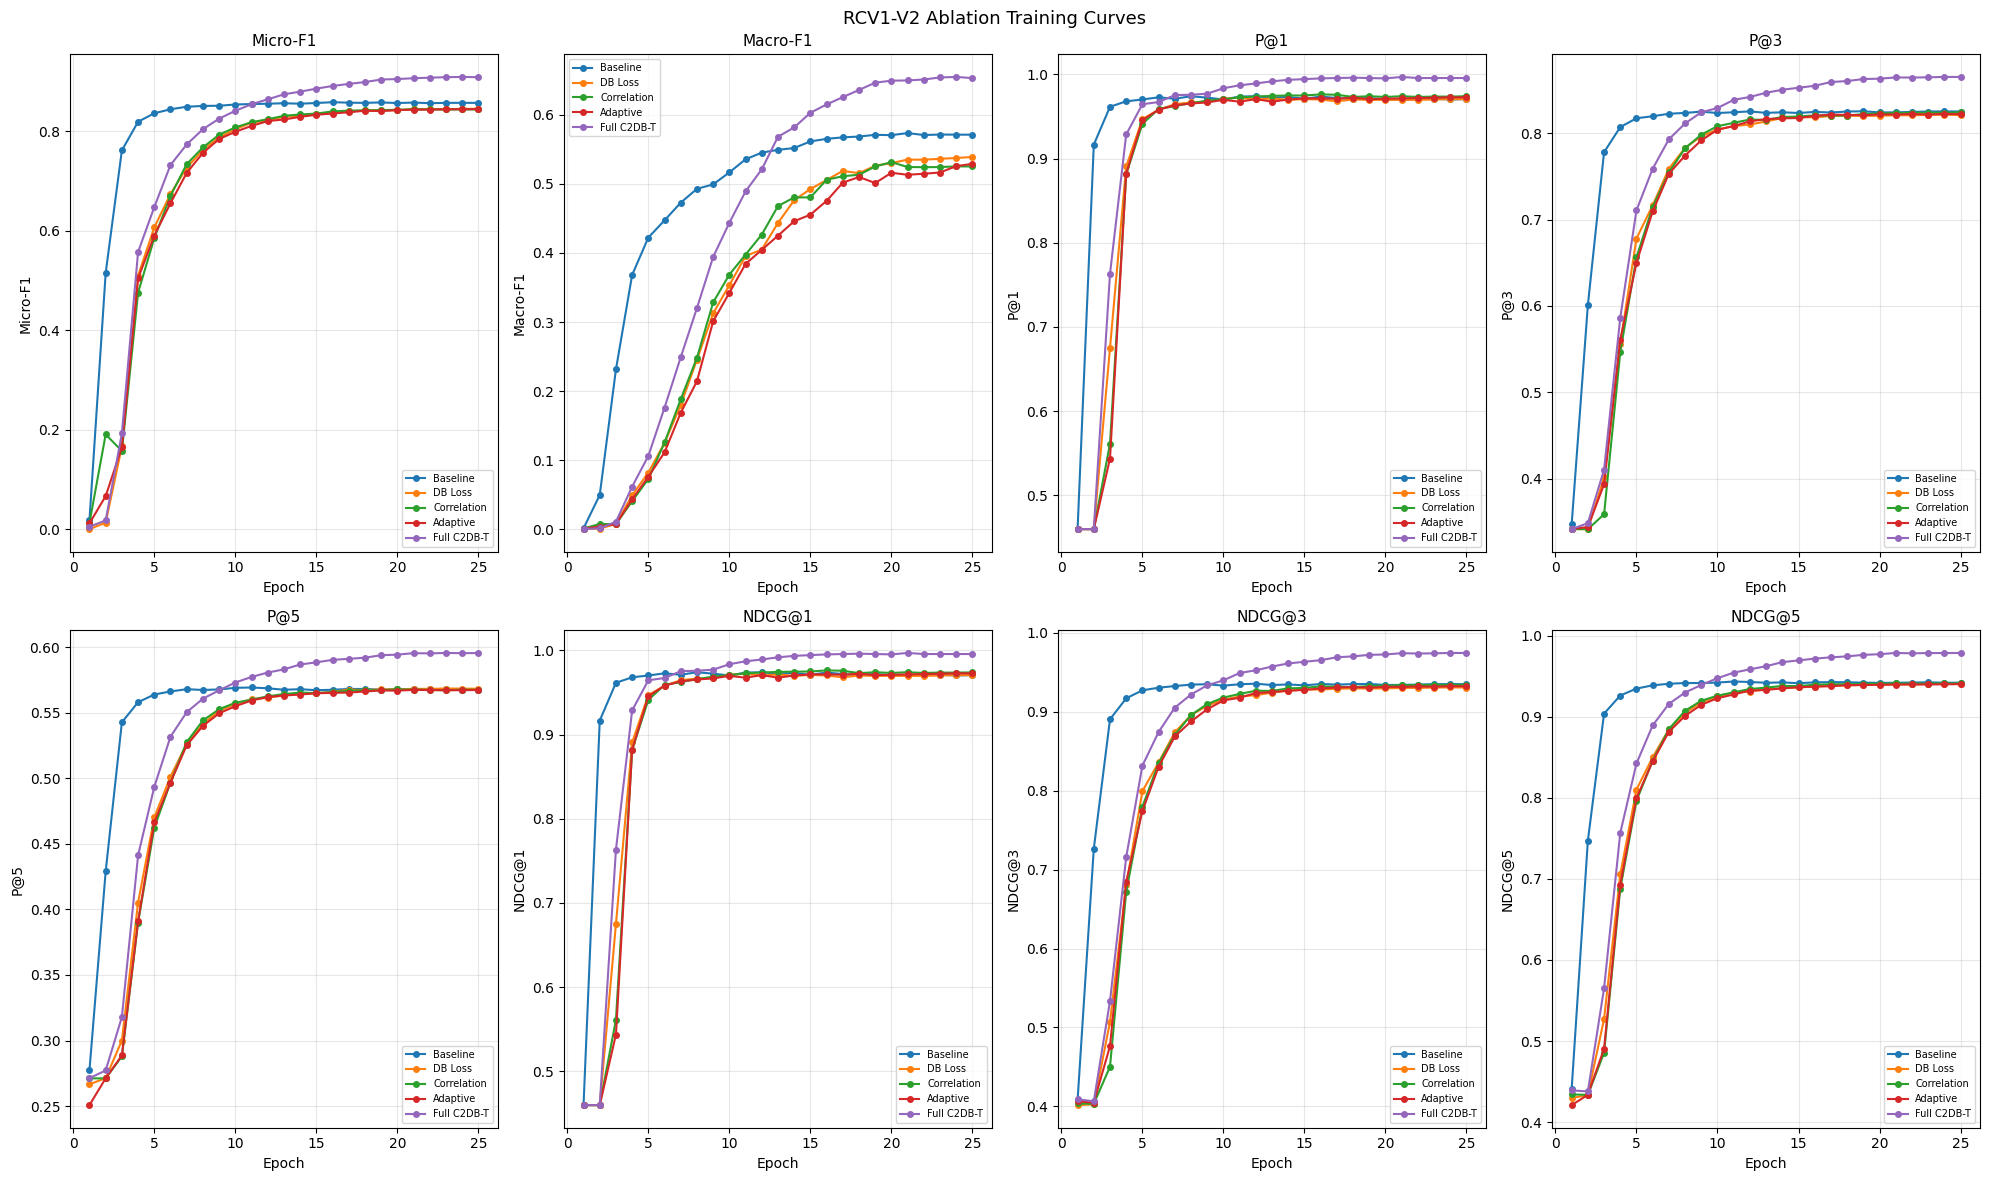

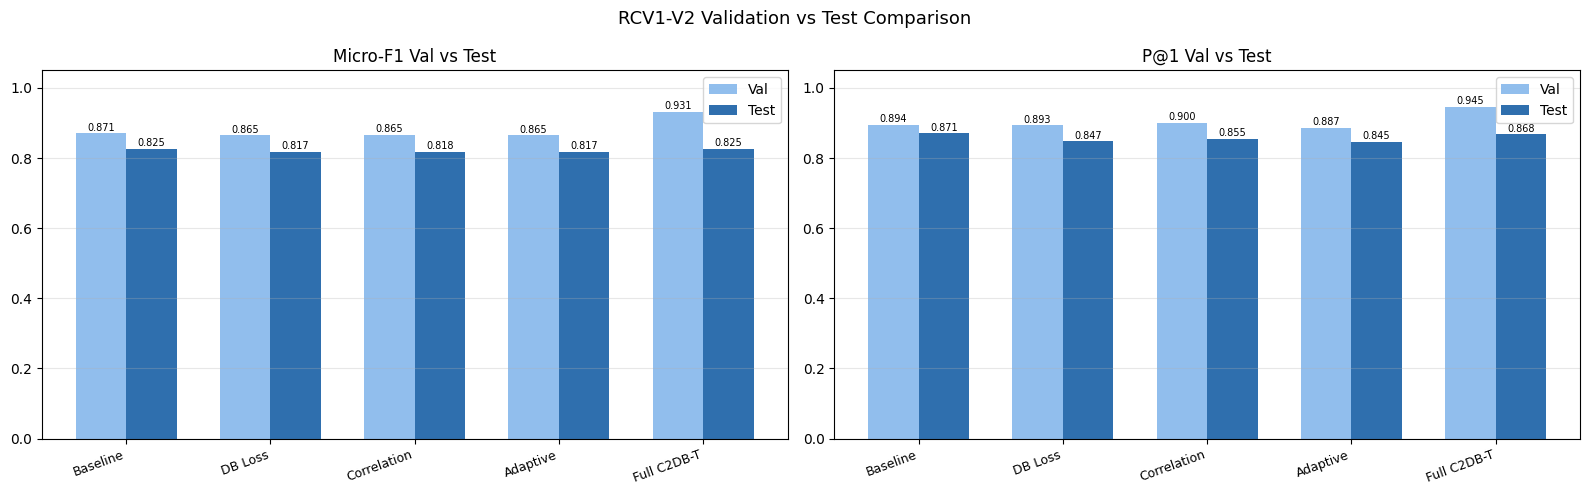

Plots saved.


In [16]:
# ── PLOTS ─────────────────────────────────────────────────────────────────────
all_hists   = [baseline_hist, db_hist, corr_hist, adapt_hist, full_hist]
model_names = ['Baseline', 'DB Loss', 'Correlation', 'Adaptive', 'Full C2DB-T']
metrics_to_plot = ['Micro-F1','Macro-F1','P@1','P@3','P@5','NDCG@1','NDCG@3','NDCG@5']

plt.figure(figsize=(20, 12))
for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 4, i+1)
    for name, hist in zip(model_names, all_hists):
        vals = hist[metric]
        plt.plot(range(1, len(vals)+1), vals, marker='o', label=name, markersize=4)
    plt.title(metric, fontsize=11); plt.xlabel('Epoch'); plt.ylabel(metric)
    plt.grid(True, alpha=0.3); plt.legend(fontsize=7)
plt.suptitle('RCV1-V2 Ablation Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rcv1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(STEPS)); w = 0.35
for ax, metric in zip(axes, ['Micro-F1', 'P@1']):
    val_v  = [tuned_results.get(s, {}).get(metric, 0) for s in STEPS]
    test_v = [test_results.get(s,  {}).get(metric, 0) for s in STEPS]
    ax.bar(x-w/2, val_v,  w, label='Val',  color='#85B7EB', alpha=0.9)
    ax.bar(x+w/2, test_v, w, label='Test', color='#185FA5', alpha=0.9)
    for xi, (v, t) in enumerate(zip(val_v, test_v)):
        ax.text(xi-w/2, v+0.002, f'{v:.3f}', ha='center', fontsize=7, va='bottom')
        ax.text(xi+w/2, t+0.002, f'{t:.3f}', ha='center', fontsize=7, va='bottom')
    ax.set_xticks(x); ax.set_xticklabels(STEPS, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{metric} Val vs Test'); ax.legend()
    ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 1.05)
plt.suptitle('RCV1-V2 Validation vs Test Comparison', fontsize=13)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rcv1_val_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved.")